In [1]:
# The following installation code are for libraries not already provided
!poetry add vaderSentiment
!poetry add "spacy>=3.8.0,<4.0.0" --python "<3.15"
!poetry run python -m spacy download en_core_web_sm

The following packages are already present in the pyproject.toml and will be skipped:

  - vaderSentiment

If you want to update it to the latest compatible version, you can use `poetry update package`.
If you prefer to upgrade it to the latest available version, you can use `poetry add package@latest`.

Nothing to add.

Updating dependencies
Resolving dependencies...

No dependencies to install or update


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 16.7 MB/s eta 0:00:01
     -------------- ------------------------- 4.7/12.8 MB 17.8 MB/s eta 0:00:01
     ------------------------------- ------- 10.5/12.8 MB 21.1 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 20.6 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import itertools
from collections import Counter

from scipy.stats import spearmanr, skew
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))

import spacy
nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\spher\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# Import evaluation data on responses
eval_G = pd.read_csv('evaluation_outputs_gain.csv') # Evaluation responses for gain-framed model
eval_L = pd.read_csv('evaluation_outputs_loss.csv') # Evaluation responses for loss-framed model

# Import training data on responses
train_G = pd.read_csv('instruction_responses.csv')[['policy', 'gain_response']] # Instruction responses for gain-framed model
train_L = pd.read_csv('instruction_responses.csv')[['policy', 'loss_response']] # Instruction responses for loss-framed model

train_G.columns = ['policy', 'response']
train_L.columns = ['policy', 'response']

### DELETE THIS PORTION; EVALUATION CODE HAS BEEN UPDATED TO CIRCUMVENT THIS ###
eval_G.drop("Unnamed: 0", axis=1, inplace=True)
eval_L.drop("Unnamed: 0", axis=1, inplace=True)
################################################################################

Question:
- Does framing explanatory responses in instruction-tuning datasets affect how language models justify policy support?

Analysis:
- confirmation that instruction framing leads to differences in explanatory behavior (compare results between gain & loss)
  - differences in vocabulary distribution between gain eval responses & loss eval responses
  - differences in sentiment distribution between gain eval responses & loss eval responses
- show if the model is just copying the instruction-tuning vocabulary (compare results between training data & evaluation data)
  - differences in vocabulary distribution between train responses & eval responses for both gain & loss

Limitations:
- instruction dataset:
  - only contained neutral-ish questions that all asked about whether a policy should be supported
    - did not have any prompts that asked if a policy should be rejected
  - only contained indirect explanations as example responses
    - cannot judge whether framing has an effect on decision behavior
    - can only judge whether framing has an effect on explanatory behavior

Further Study:
- try instruction tuning less?
  - even without signs overfitting, perhaps training to the point of very low validation and train losses is counterproductive as it entirely supplants the original model's reasoning methods with the reasoning found in the instruction tuning data, essentially trivially copying the instruction tuning data

Analysis points:
1. models use different language under different framing; justification style is affected
  - sentiment distributions
  - log-odd ratios (some words are highly associated with either gain/loss-framing)
2. framing patterns learned in training persist in evaluation
  - correlation of train & eval log-odds (words associated with either gain/loss-framing in instruction responses continue to do so in evaludation; i.e. aligned)
  - suggests that the model learned which models signal gain/loss framing

## Vocabulary analysis

In [256]:
# Helper functions
def tokenize(text):
    '''Tokenization for strings via spacy.'''
    doc = nlp(text)
    return [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop]

def flatten_list(lst):
    '''Flattens lists of lists.'''
    return list(itertools.chain.from_iterable(lst))

def get_rel_freqs(counter):
    '''Converts counts in a Counter to dict of relative frequencies.'''
    total = sum(counter.values())
    return {w: c/total for w, c in counter.items()}

def get_pos_tokens(text, pos_tags={'VERB', 'ADJ', 'ADV'}):
    '''
    Returns tokens that have specified parts of speech.
    Args:
        text (str):             English sentence
        pos_tags (set of str):  Set of part-of-speech tags (default: verbs, adjectives, adverbs)
    Returns:
        tokens (list of str):   Tokens in sentence that match pos_tags
    '''
    doc = nlp(text)
    tokens = []

    for token in doc:
        if token.pos_ in pos_tags:
            tokens.append(token.lemma_.lower())
    
    return tokens

def get_shared_words(counter1, counter2):
    '''Returns list of shared counter keys that have nonzero counts in both counters'''
    shared = [w for w in counter1.keys() if w in counter2.keys() and counter1[w] > 0 and counter2[w] > 0]
    return shared

In [264]:
# Creating dict to keep outputs organized
response_sets = {
    'train_G': train_G, 
    'train_L': train_L, 
    'eval_G': eval_G, 
    'eval_L': eval_L
}
findings = {
    'train_G': dict(),
    'train_L': dict(),
    'eval_G': dict(),
    'eval_L': dict()
}

for rs in response_sets:
    # Get verbs, adjectives, and adverbs
    findings[rs]['verbs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'VERB'},)).tolist())
    findings[rs]['adjs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'ADJ'},)).tolist())
    findings[rs]['advs'] = flatten_list(response_sets[rs]['response'].apply(get_pos_tokens, args=({'ADV'},)).tolist())

    # Get counts for each PoS
    findings[rs]['verbs_counts_raw'] = Counter(findings[rs]['verbs'])
    findings[rs]['adjs_counts_raw'] = Counter(findings[rs]['adjs'])
    findings[rs]['advs_counts_raw'] = Counter(findings[rs]['advs'])

    # Filter out words that occur less than n times
    filter_n = 1
    findings[rs]['verbs_counts'] = Counter({w: c for w, c in findings[rs]['verbs_counts_raw'].items() if c >= filter_n})
    findings[rs]['adjs_counts'] = Counter({w: c for w, c in findings[rs]['adjs_counts_raw'].items() if c >= filter_n})
    findings[rs]['advs_counts'] = Counter({w: c for w, c in findings[rs]['advs_counts_raw'].items() if c >= filter_n})

    # Convert raw counts to sorted relative frequency series for each PoS
    findings[rs]['verbs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['verbs_counts'])).sort_values(ascending=False)
    findings[rs]['adjs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['adjs_counts'])).sort_values(ascending=False)
    findings[rs]['advs_freqs'] = pd.Series(get_rel_freqs(findings[rs]['advs_counts'])).sort_values(ascending=False)

### Framing associations

Certain words may be more associated with gain-framing or loss-framing. This association can be quantified by a word's log-odds ratio as $\log \left( \frac{P(\text{word}|\text{gain})}{P(\text{word}|\text{loss})} \right)$.

A positive log-odds ratio indicates association with gain framing.
A negative log-odds ratio indicates association with loss framing.
A near-zero log-odds ratio indicates similar usage in both gain and loss framing.

In [265]:
def get_log_odds_ratios(gain_freqs, loss_freqs, epsilon=1e-12):
    '''
    Computes log-odds ratios for a Series containing words and their respective relative frequencies. 
    Calculates according to ln(P(word|gain)/P(word|loss)).

    Args:
        gain_freqs (Series):    Series of relative word frequencies for a gain-framed response set
        loss_freqs (Series):    Series of relative word frequencies for a loss-framed response set
        epsilon:                Small positive value to avoid log(0) 

    Returns:
        log_odds (Series):      Series of log-odds for all words across gain_freqs and loss_freqs
    '''
    # Make both series have identical indices
    all_words = list(set(gain_freqs.index) | set(loss_freqs.index))
    g = gain_freqs.reindex(all_words, fill_value=0.0)   # Missing words given a frequency of 0
    l = loss_freqs.reindex(all_words, fill_value=0.0)

    # Adjust frequencies of 0
    g += epsilon
    l += epsilon

    log_odds = pd.Series(np.log(g/l), index=all_words)

    return log_odds

In [266]:
# Get shared words that occur nonzero times in both gain & loss response sets
train_verb_shared = get_shared_words(findings['train_G']['verbs_counts'], findings['train_L']['verbs_counts'])
train_adj_shared = get_shared_words(findings['train_G']['adjs_counts'], findings['train_L']['adjs_counts'])
train_adv_shared = get_shared_words(findings['train_G']['advs_counts'], findings['train_L']['advs_counts'])

eval_verb_shared = get_shared_words(findings['eval_G']['verbs_counts'], findings['eval_L']['verbs_counts'])
eval_adj_shared = get_shared_words(findings['eval_G']['adjs_counts'], findings['eval_L']['adjs_counts'])
eval_adv_shared = get_shared_words(findings['eval_G']['advs_counts'], findings['eval_L']['advs_counts'])

In [273]:
# Get log odds for instruction & evaluation responses (all words)
train_verb_log_odds = get_log_odds_ratios(findings['train_G']['verbs_freqs'], findings['train_L']['verbs_freqs']).sort_values(ascending=False)
train_adj_log_odds = get_log_odds_ratios(findings['train_G']['adjs_freqs'], findings['train_L']['adjs_freqs']).sort_values(ascending=False)
train_adv_log_odds = get_log_odds_ratios(findings['train_G']['advs_freqs'], findings['train_L']['advs_freqs']).sort_values(ascending=False)

eval_verb_log_odds = get_log_odds_ratios(findings['eval_G']['verbs_freqs'], findings['eval_L']['verbs_freqs']).sort_values(ascending=False)
eval_adj_log_odds = get_log_odds_ratios(findings['eval_G']['adjs_freqs'], findings['eval_L']['adjs_freqs']).sort_values(ascending=False)
eval_adv_log_odds = get_log_odds_ratios(findings['eval_G']['advs_freqs'], findings['eval_L']['advs_freqs']).sort_values(ascending=False)

# Get log odds for instruction & evaluation responses (shared words only)
train_verb_log_odds_shared = get_log_odds_ratios(findings['train_G']['verbs_freqs'][train_verb_shared], findings['train_L']['verbs_freqs'][train_verb_shared]).sort_values(ascending=False)
train_adj_log_odds_shared = get_log_odds_ratios(findings['train_G']['adjs_freqs'][train_adj_shared], findings['train_L']['adjs_freqs'][train_adj_shared]).sort_values(ascending=False)
train_adv_log_odds_shared = get_log_odds_ratios(findings['train_G']['advs_freqs'][train_adv_shared], findings['train_L']['advs_freqs'][train_adv_shared]).sort_values(ascending=False)

eval_verb_log_odds_shared = get_log_odds_ratios(findings['eval_G']['verbs_freqs'][eval_verb_shared], findings['eval_L']['verbs_freqs'][eval_verb_shared]).sort_values(ascending=False)
eval_adj_log_odds_shared = get_log_odds_ratios(findings['eval_G']['adjs_freqs'][eval_adj_shared], findings['eval_L']['adjs_freqs'][eval_adj_shared]).sort_values(ascending=False)
eval_adv_log_odds_shared = get_log_odds_ratios(findings['eval_G']['advs_freqs'][eval_adv_shared], findings['eval_L']['advs_freqs'][eval_adv_shared]).sort_values(ascending=False)

In [274]:
# Get the n most extreme words
top_n = 10

eval_verb_most_gain = eval_verb_log_odds_shared.head(top_n)
eval_verb_most_loss = eval_verb_log_odds_shared.tail(top_n)
eval_verb_extremes = pd.concat([eval_verb_most_gain, eval_verb_most_loss]).sort_values(ascending=True)

eval_adj_most_gain = eval_adj_log_odds_shared.head(top_n)
eval_adj_most_loss = eval_adj_log_odds_shared.tail(top_n)
eval_adj_extremes = pd.concat([eval_adj_most_gain, eval_adj_most_loss]).sort_values(ascending=True)

eval_adv_most_gain = eval_adv_log_odds_shared.head(top_n)
eval_adv_most_loss = eval_adv_log_odds_shared.tail(top_n)
eval_adv_extremes = pd.concat([eval_adv_most_gain, eval_adv_most_loss]).sort_values(ascending=True)

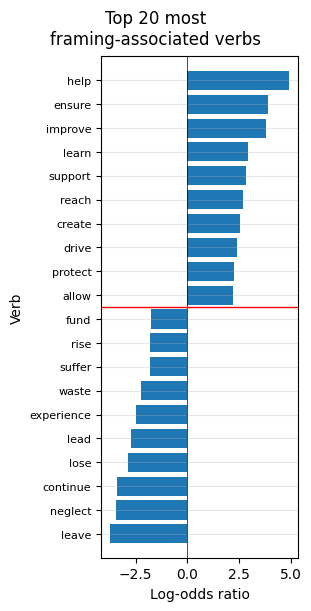

In [275]:
# Visualize extreme verbs
fig, ax = plt.subplots(figsize=(3,6), layout='constrained')
fig.suptitle(f'Top {top_n*2} most\nframing-associated verbs')

ax.barh(eval_verb_extremes.index, eval_verb_extremes.values)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Log-odds ratio')
ax.set_ylabel('Verb')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axhline(y=top_n-0.5, color='red', linewidth=1)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-1, len(eval_verb_extremes.index))

plt.show()

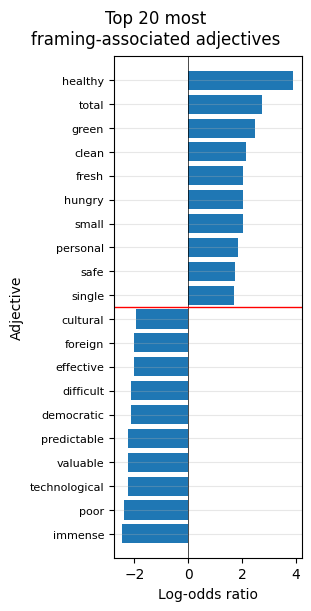

In [276]:
# Visualize extreme adjectives
fig, ax = plt.subplots(figsize=(3,6), layout='constrained')
fig.suptitle(f'Top {top_n*2} most\nframing-associated adjectives')

ax.barh(eval_adj_extremes.index, eval_adj_extremes.values)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Log-odds ratio')
ax.set_ylabel('Adjective')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axhline(y=top_n-0.5, color='red', linewidth=1)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-1, len(eval_adj_extremes.index))

plt.show()

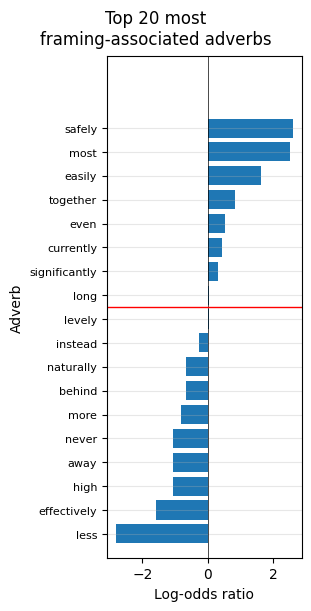

In [277]:
# Visualize extreme adverbs
fig, ax = plt.subplots(figsize=(3,6), layout='constrained')
fig.suptitle(f'Top {top_n*2} most\nframing-associated adverbs')

ax.barh(eval_adv_extremes.index, eval_adv_extremes.values)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Log-odds ratio')
ax.set_ylabel('Adverb')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.axhline(y=top_n-0.5, color='red', linewidth=1)
ax.yaxis.grid(True, alpha=0.3)
ax.set_ylim(-1, len(eval_adv_extremes.index))

plt.show()

### Emergent vocabulary

It is easy to show that framing instruction responses affected the model's response style in evaluation prompts. However, these results may be trivial. Specifically, the model could have either trivially copied the instruction data (memorization-like behavior), or the model could have learned the reasoning patterns in the instruction data (generalization).

A hypothesis is that the memorization scenario would result in the evaluation responses having a log-odds distribution that is nearly identical to the log-odds distribution of the instruction responses (i.e. very high correlation between train & eval log-odds, lack of novelty). Likewise, the learning scenario would yield moderate similarities between the train and evaluation distributions (i.e. preserves patterns, but still allows for variability).

In [278]:
# Find emergent vocabulary (words that exist in evaluation but not training)
gain_new_verbs = [w for w in findings['eval_G']['verbs_freqs'].index.tolist() if w not in findings['train_G']['verbs_freqs'].index.tolist()]
gain_new_adjs = [w for w in findings['eval_G']['adjs_freqs'].index.tolist() if w not in findings['train_G']['adjs_freqs'].index.tolist()]
gain_new_advs = [w for w in findings['eval_G']['advs_freqs'].index.tolist() if w not in findings['train_G']['advs_freqs'].index.tolist()]

loss_new_verbs = [w for w in findings['eval_L']['verbs_freqs'].index.tolist() if w not in findings['train_L']['verbs_freqs'].index.tolist()]
loss_new_adjs = [w for w in findings['eval_L']['adjs_freqs'].index.tolist() if w not in findings['train_L']['adjs_freqs'].index.tolist()]
loss_new_advs = [w for w in findings['eval_L']['advs_freqs'].index.tolist() if w not in findings['train_L']['advs_freqs'].index.tolist()]

# See if those novel words have framings consistent with their intended framing
gain_new_verbs_log_odds = eval_verb_log_odds.loc[gain_new_verbs].sort_values(ascending=False)
gain_new_adjs_log_odds = eval_adj_log_odds.loc[gain_new_adjs].sort_values(ascending=False)
gain_new_advs_log_odds = eval_adv_log_odds.loc[gain_new_advs].sort_values(ascending=False)

loss_new_verbs_log_odds = eval_verb_log_odds.loc[loss_new_verbs].sort_values(ascending=True)
loss_new_adjs_log_odds = eval_adj_log_odds.loc[loss_new_adjs].sort_values(ascending=True)
loss_new_advs_log_odds = eval_adv_log_odds.loc[loss_new_advs].sort_values(ascending=True)

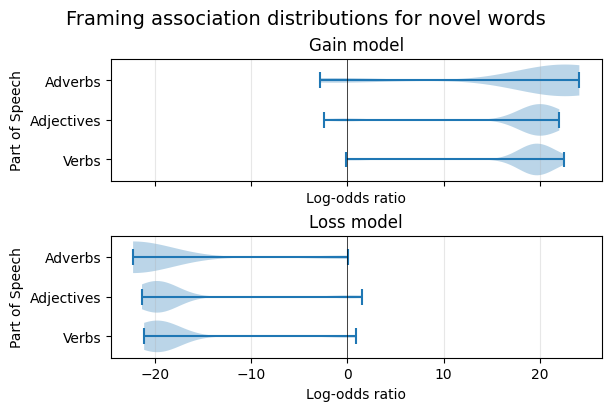

In [279]:
# Visualize the log-odds distributions of the novel words
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6,4), layout='constrained', sharex=True)
fig.suptitle('Framing association distributions for novel words', fontsize=14)

ax1.violinplot([gain_new_verbs_log_odds, gain_new_adjs_log_odds, gain_new_advs_log_odds], 
               orientation='horizontal', widths=0.8)
ax1.set_yticks([1,2,3])
ax1.set_yticklabels(['Verbs', 'Adjectives', 'Adverbs'])
ax1.set_ylabel('Part of Speech')
ax1.set_xlabel('Log-odds ratio')
ax1.set_title('Gain model', fontsize=12)

ax1.axvline(x=0, color='black', linewidth=0.5)
ax1.xaxis.grid(True, alpha=0.3)

ax2.violinplot([loss_new_verbs_log_odds, loss_new_adjs_log_odds, loss_new_advs_log_odds], 
               orientation='horizontal', widths=0.8)
ax2.set_yticks([1,2,3])
ax2.set_yticklabels(['Verbs', 'Adjectives', 'Adverbs'])
ax2.set_ylabel('Part of Speech')
ax2.set_xlabel('Log-odds ratio')
ax2.set_title('Loss model', fontsize=12)

ax2.axvline(x=0, color='black', linewidth=0.5)
ax2.xaxis.grid(True, alpha=0.3)

plt.show()

### Rank correlation

See the extent to which word rankings by framing strength (log-odds ratio) are correlated between the train and evaluation sets. 

In [281]:
def compute_spearmanr_log_odds(train_log_odds, eval_log_odds):
    '''
    Computes the Spearman R correlation and p-value for train & eval log odds.

    Args:
        train_log_odds (Series):    Log-odds for some set of words from the instruction responses
        eval_log_odds (Series):     Log-odds for some set of words from the evaluation responses
    Returns:
        corr, pval
    '''
    # Exclude words not in both series
    common_words = list(set(train_log_odds.index) & set(eval_log_odds.index))

    x = train_log_odds[common_words]
    y = eval_log_odds[common_words]

    corr, pval = spearmanr(x,y)
    return corr, pval

In [282]:
print(compute_spearmanr_log_odds(train_verb_log_odds_shared, eval_verb_log_odds_shared))
print(compute_spearmanr_log_odds(train_adj_log_odds_shared, eval_adj_log_odds_shared))
print(compute_spearmanr_log_odds(train_adv_log_odds_shared, eval_adv_log_odds_shared))

(0.7136805507480465, 8.62868013500099e-15)
(0.5204674826538227, 4.3621607475668386e-11)
(0.6607698365454268, 0.005326394470219712)


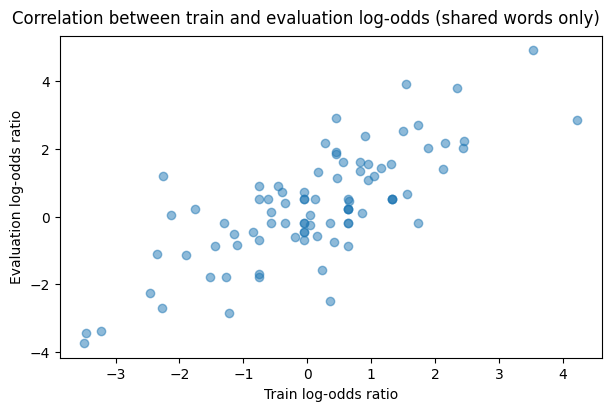

In [285]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(6,4), layout='constrained')
fig.suptitle(f'Correlation between train and evaluation log-odds (shared words only)')

common_words = list(set(train_verb_log_odds_shared.index) & set(eval_verb_log_odds_shared.index))
x = train_verb_log_odds[common_words]
y = eval_verb_log_odds[common_words]

ax.scatter(x, y, alpha=0.5)
ax.set_xlabel('Train log-odds ratio')
ax.set_ylabel('Evaluation log-odds ratio')

plt.show()

## Sentiment analysis

In [286]:
analyzer = SentimentIntensityAnalyzer()

eval_G['sentiment'] = eval_G['response'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
eval_L['sentiment'] = eval_L['response'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

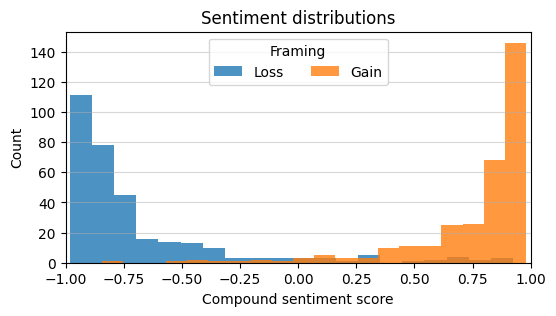

In [291]:
fig, ax = plt.subplots(figsize=(6,3))

ax.hist(eval_L['sentiment'], bins=20, alpha=0.8, label='Loss')
ax.hist(eval_G['sentiment'], bins=20, alpha=0.8, label='Gain')

ax.set_title('Sentiment distributions')
ax.set_ylabel('Count')
ax.set_xlabel('Compound sentiment score')
ax.set_xlim(-1.0, 1.0)
ax.legend(loc='upper center', ncols=2, title='Framing')
ax.yaxis.grid(True, alpha=0.5)
plt.show()